# _**Plotting Magnetic Vector Field Data**_
===========================

This Notebook script contains code cells that plot time series of the vector magneticfield data from MagIE and the IAGA GIN for user defined input parameters. Script can download GIN one-minute (or one-second) data. Downloads MagIE one-second data. Some code cells can perform basic data anlaysis.

In [6]:
import os
os.chdir("../src")
os.getcwd()

'/Users/guanrenwang/Desktop/MAGIE/src'

### Import standard python libraries and other conventional libraries

In [48]:
from pathlib import Path
import datetime as dt
import numpy as np
import pandas as pd
import shutil
from os import path as pth

### Import functions from MagIE modules

In [72]:
from magie.Data_Download import get_GIN_data
from magie.Data_Download import download_magie
from magie.Data_Processing import one_minute_sampling
from magie.Data_Processing import fix_timestamp_duplicates
from magie.Data_Processing import fix_missing_timestamps
from magie.Data_Processing import means_calc
from magie.Data_Processing import compute_H
from magie.Plots import plot_xyzf
from magie.Plots import stack_plot

## Define input parameters
The IAGA Code is the official IAGA 3-letter station code. It should be in capital letters and correspond to the IAGA list of magnetic observatories. 
Data duration are in integer days. Orientation is best set to XYZF or DHZF (some observatories may not publish D and H-components).
Output file path is set to the Data Directory of MagIE.

In [ ]:
start_time = dt.datetime(2025, 11, 11, 12, 0, 0)
end_time = dt.datetime(2025, 11, 12, 23, 59, 59)
np_start_time = np.datetime64(start_time, 's')
np_end_time = np.datetime64(end_time, 's')
iagaSites = ["ESK", "HAD", "WNG", "NGK"]
dataDuration = 2
orientation = "XYZF"
output_file_path = Path(r'../Data/')

## Download GIN data in IAGA-2002 format then quick check to view GIN time series.
Optional argument samples="Minute", use samples="Second" if requiring one-second data. state="best-avail" for best avialable data. Set state="definitive" for one-minute definitive data. There are no definitive one-second data.

2 day(s) of 2025-11-11 data 
        for ESK is getting extracted from:
https://imag-data.bgs.ac.uk/GIN_V1/GINServices?Request=GetData&observatoryIagaCode=ESK&samplesPerDay=Minute&dataStartDate=2025-11-11&dataDuration=2&publicationState=best-avail&Format=iaga2002&orientation=XYZF&%26recordTermination=UNIX
Mandatory file header records
0: [Format                 IAGA-2002]
1: [Source of Data         British Geological Survey (BGS)]
2: [Station Name           Eskdalemuir]
3: [IAGA Code              ESK]
4: [Geodetic Latitude      55.317]
5: [Geodetic Longitude     356.800]
6: [Elevation              245]
7: [Reported               XYZF]
8: [Sensor Orientation     HDZF]
9: [Digital Sampling       1-second]
10: [Data Interval Type     1-minute (00:30 - 01:30)]
11: [Data Type              quasi-definitive]
12: [Publication Date       2025-11-13]
13: [# Data file created on 12-11-2025 at 15:14:22]
14: [#]
15: [# This data file was created by the BGS geomagnetic data processing]
16: [# softwa

/Users/guanrenwang/Desktop/MAGIE/src/magie/Plots.py:348: UserWarning: The following requested columns are missing and will be skipped:['ESKX', 'ESKY', 'ESKZ', 'ESKF']
  warnings.warn(


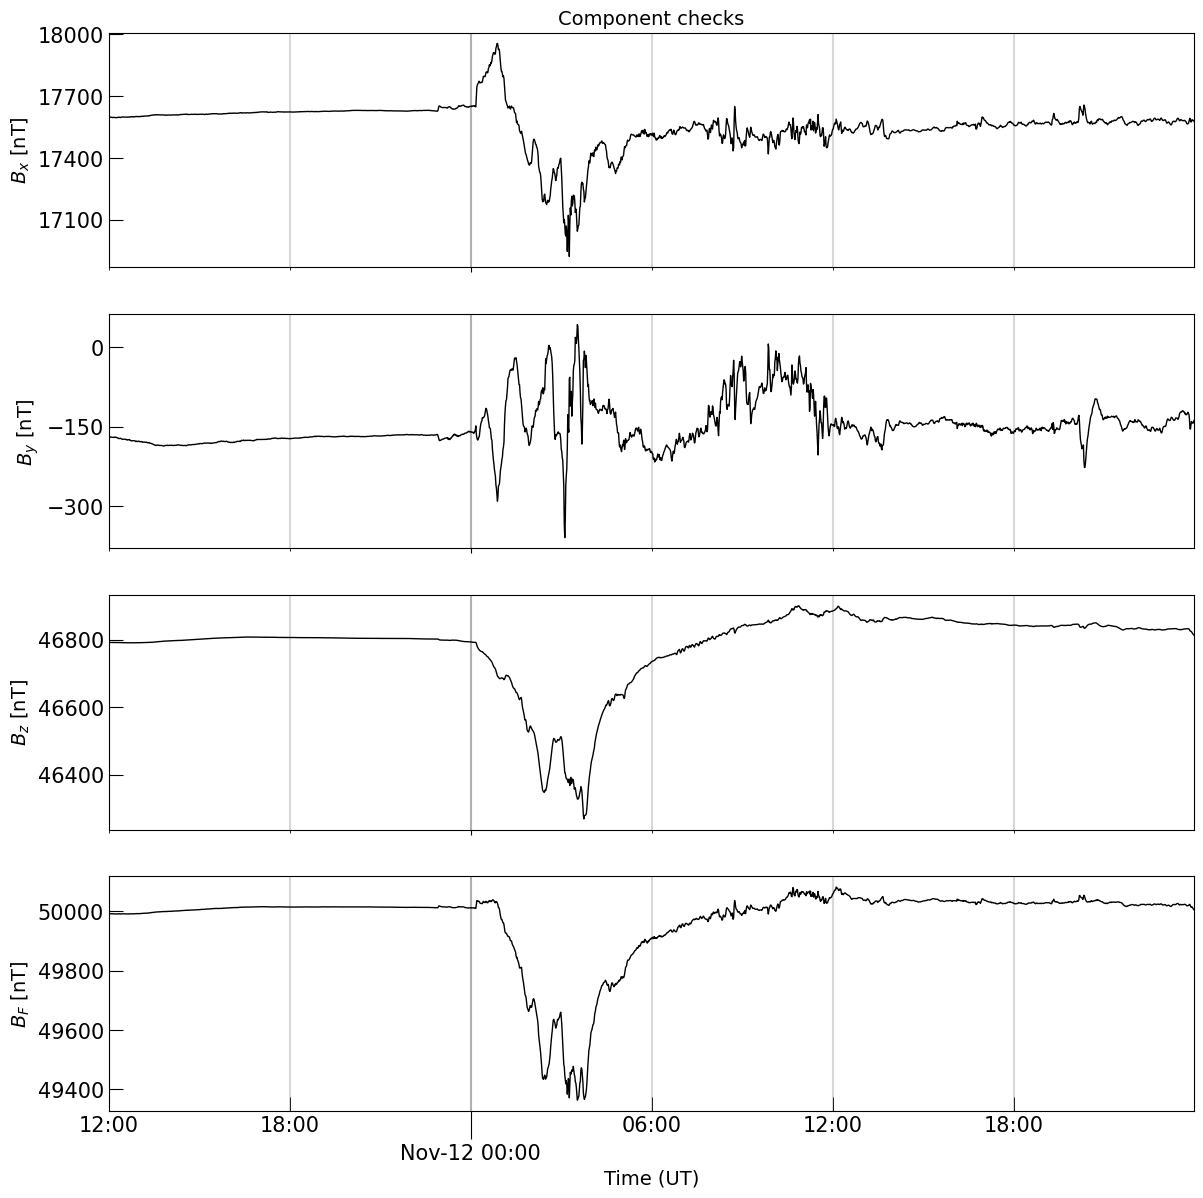

HAD
Plot is saved in ../Data/Check_GIN_data.png


/Users/guanrenwang/Desktop/MAGIE/src/magie/Plots.py:348: UserWarning: The following requested columns are missing and will be skipped:['HADX', 'HADY', 'HADZ', 'HADF']
  warnings.warn(


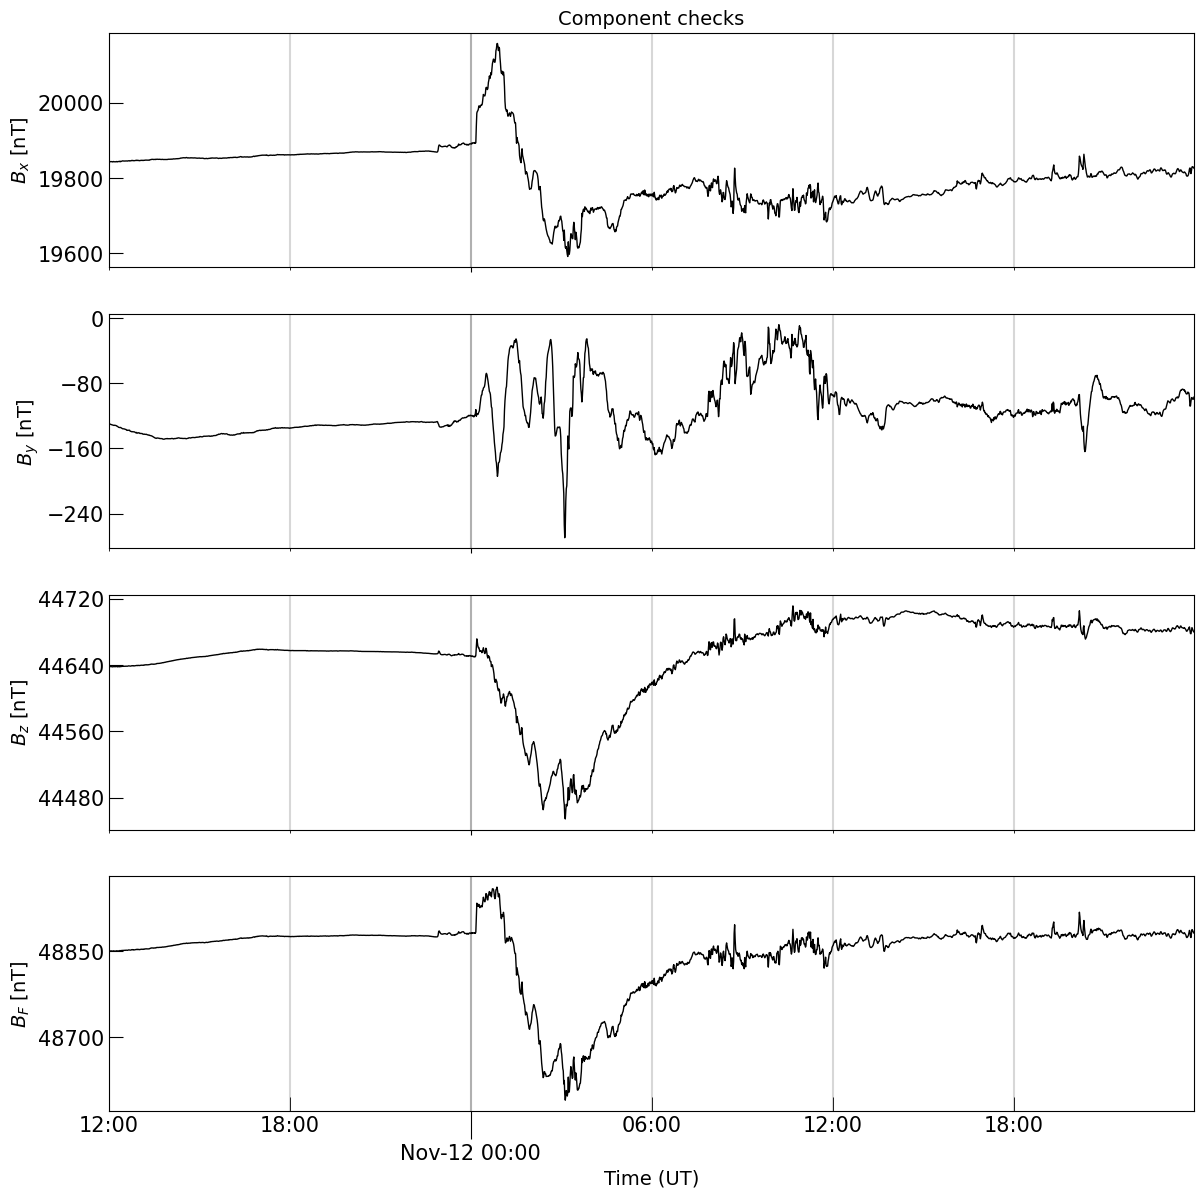

WNG
Plot is saved in ../Data/Check_GIN_data.png


/Users/guanrenwang/Desktop/MAGIE/src/magie/Plots.py:348: UserWarning: The following requested columns are missing and will be skipped:['WNGX', 'WNGY', 'WNGZ', 'WNGF']
  warnings.warn(


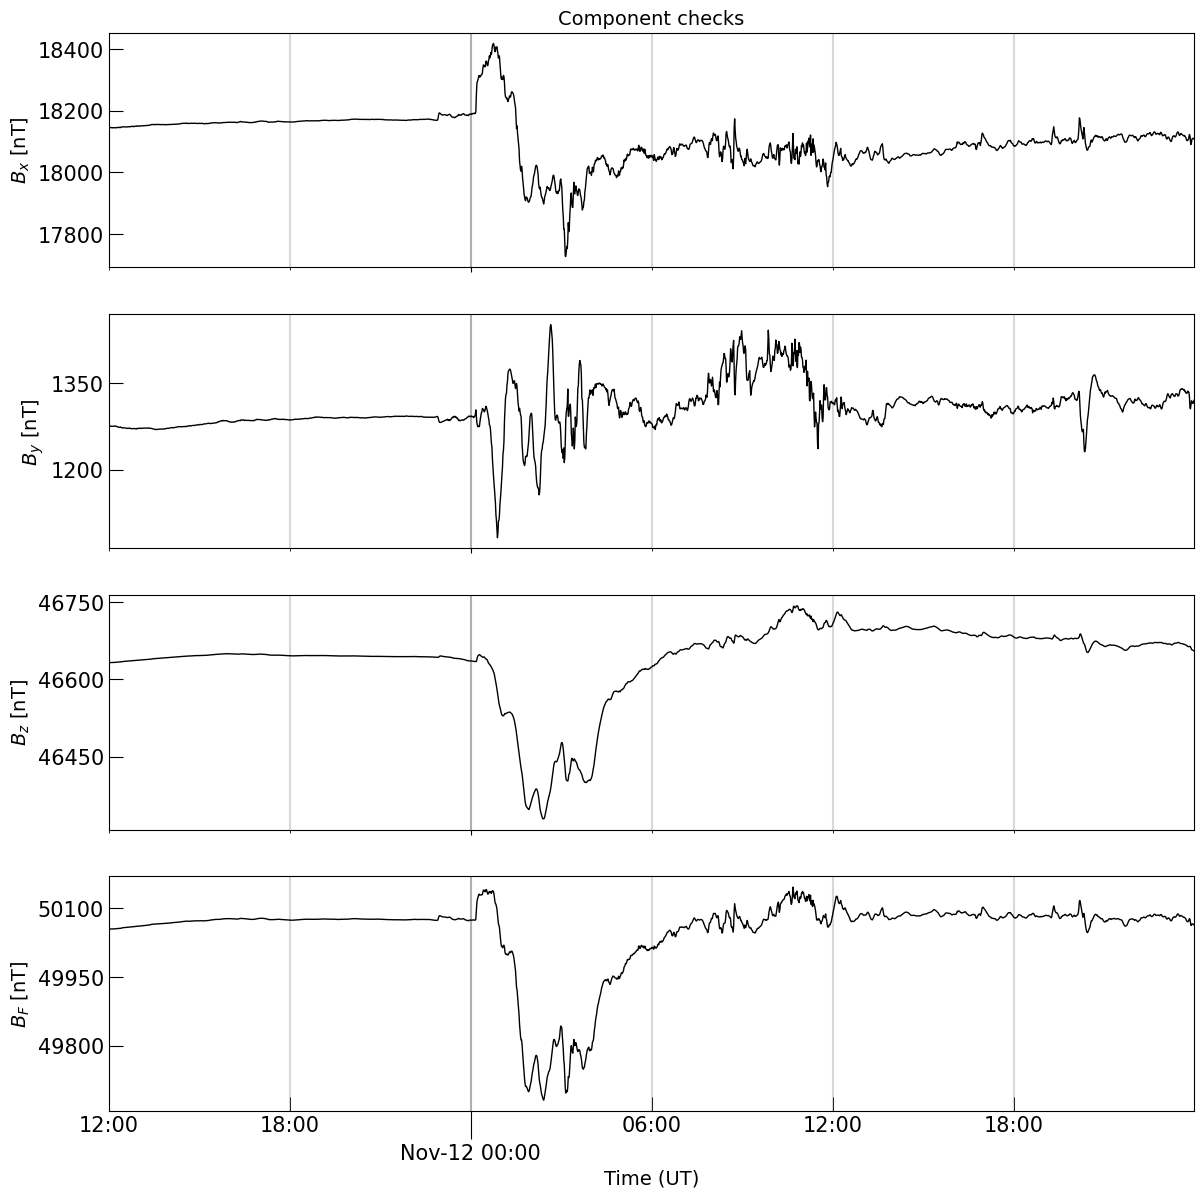

NGK


/Users/guanrenwang/Desktop/MAGIE/src/magie/Plots.py:348: UserWarning: The following requested columns are missing and will be skipped:['NGKX', 'NGKY', 'NGKZ', 'NGKF']
  warnings.warn(


Plot is saved in ../Data/Check_GIN_data.png


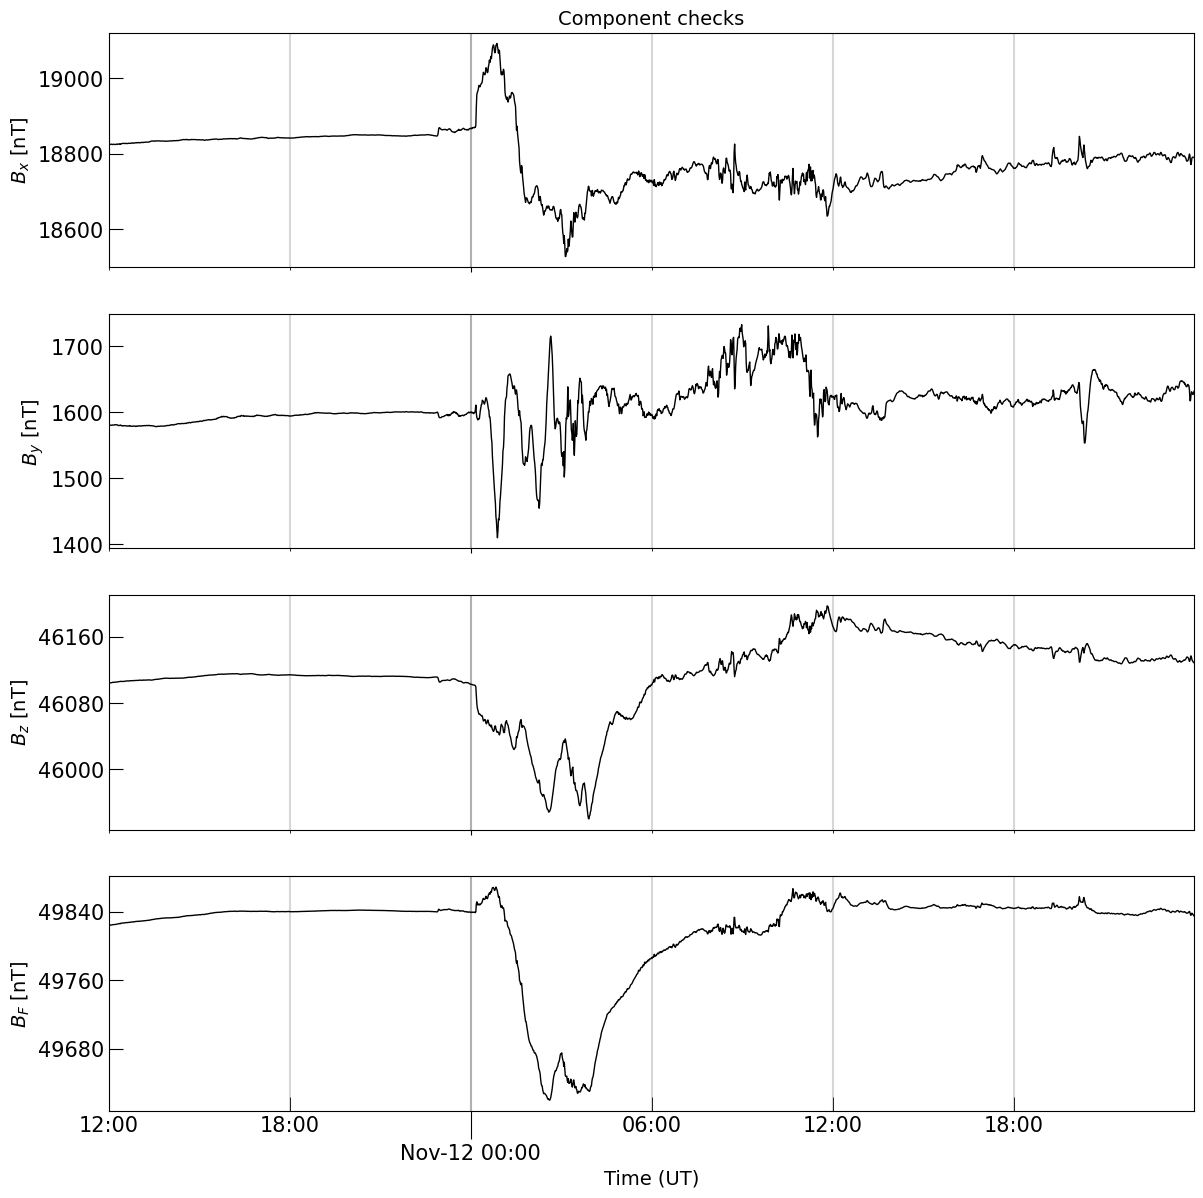

In [46]:
df_GIN = get_GIN_data(start_time, iagaSites, dataDuration, orientation)
title = "Component checks"
outfile = "Check_GIN_data.png"
ff = pth.join(output_file_path, outfile)
for obs in iagaSites:
    plot_xyzf(df_GIN, obs, start_time, end_time, title, ff, comps=["X", "Y", "Z", "F"])

## Download MagIE data as hdf5 file and perfom basic data processing.
Default file name generated instead of using save_file_name option is in the form of "dun_val2025_11_11_to_2025_11_12.hdf5". At the moment this function 
Save raw one-second magnetometer data to dataframe then account for any duplicated timestamps or missing timestamps. Convert one-second to one-minute data.

In [56]:
download_magie(np_start_time, np_end_time, sites=['dun', 'val'])
infile = "dun_val2025_11_11_to_2025_11_12.hdf5"
os.makedirs("../Data", exist_ok=True)
shutil.move(infile, "../Data/")
file_path = pth.join(output_file_path, infile)

  0%|          | 0/2 [00:00<?, ?it/s]

Downloading: 100.00% [4448256/4440146 bytes]
Download complete!
Downloading: 100.00% [81920/73819 bytes]

 50%|█████     | 1/2 [00:01<00:01,  1.05s/it]


Download complete!
Downloading: 100.00% [4489216/4486917 bytes]
Download complete!
Downloading: 100.00% [81920/73819 bytes]

100%|██████████| 2/2 [00:02<00:00,  1.13s/it]


Download complete!


In [67]:
df = pd.read_hdf(file_path, columns=['Date_UTC', 'Site', 'Bx', 'By', 'Bz'])

# Remove timezone after checking that it is UTC
df["Date_UTC"] = df["Date_UTC"].dt.tz_localize(None)

# assign individual dataframes for each site
df_dun = df[df['Site'].str.contains("dun")]
df_val = df[df['Site'].str.contains("val")]

# sort indexing in chronological order
df_dun = df_dun.set_index('Date_UTC')
df_val = df_val.set_index('Date_UTC')
df_val = df_val.sort_index()

# filter for start and end UTC times
df_dun = df_dun.loc[start_time:end_time]
df_val = df_val.loc[start_time:end_time]
df_GIN = df_GIN.loc[start_time:end_time]

# check for duplicates
dun_duplicates = df_dun.index[df_dun.index.duplicated()]

# fix duplicates
df_dun_duplicates_fixed = fix_timestamp_duplicates(df_dun)
df_dun_full = fix_missing_timestamps(df_dun_duplicates_fixed)

df_val = df_val.rename(columns={"Bx": "VALX", "By": "VALY", "Bz": "VALZ"})
df_dun_full = df_dun_full.rename(columns={"Bx": "DUNX",
                                            "By": "DUNY",
                                            "Bz": "DUNZ"})
df_val_minute = df_val.drop(columns=['Site'])

# run these lines if start_time and end_time don't end on full-minute
# Find the last full minute at Dunsink round down to nearest minute
last_minute = df_dun_full.index[-1].floor('min')
# Only keep rows with timestamp < next minute so it is divisible by 60 s
df_dun_full = df_dun_full[df_dun_full.index <= last_minute]

Bx_minute, Bx_resampled = one_minute_sampling(df_dun_full['DUNX'])
By_minute, Bz_resampled = one_minute_sampling(df_dun_full['DUNY'])
Bz_minute, Bz_resampled = one_minute_sampling(df_dun_full['DUNZ'])
timestamps_minute = Bx_minute.index

# Create a new DataFrame for one-minute Dunsink values
df_dun_minute = pd.DataFrame({
        'DUNX': Bx_minute,
        'DUNY': By_minute,
        'DUNZ': Bz_minute
        }, index=timestamps_minute)

print("start time: ", df_dun_minute.index.min(),
        "end time: ", df_dun_minute.index.max())

# put all the one minute files in the same dataframe
df_minute_obs = pd.concat([df_GIN, df_val_minute, df_dun_minute], axis=1)
df_minute_obs['DOY'] = df_minute_obs['DOY'].fillna(0).astype(int)

start time:  2025-11-11 12:00:00 end time:  2025-11-12 23:59:00


Concatenate all one-minnute data together

In [68]:
# find the mean values of all the observatory data that requires plotting
means = {}
obs_plot_list = ['esk', 'wng', 'dun', 'ngk', 'val', 'had']
# obs_plot_list = ['dun', 'val']
for obs in obs_plot_list:
    ob = obs.upper()
    df_minute_obs = compute_H(df_minute_obs, ob)
    # df_minute_obs = derivatives_calc_second(df_minute_obs, ob)
    means[ob] = means_calc(df_minute_obs, ob, 10)

# sort columns so that same observatory columns stay grouped
df_minute_obs = df_minute_obs[sorted(
    df_minute_obs.columns, key=lambda c: (c[:-1], c[-1])
)]


## Create subplots of the field variations in each component

Using vertical spacing of 155 nT
ESK X mean is:  17618.517683333335 nT
WNG X mean is:  18162.437550000002 nT
DUN X mean is:  18853.832690960455 nT
NGK X mean is:  18839.7886 nT
VAL X mean is:  19522.04968333333 nT
HAD X mean is:  19858.23591666667 nT
ESK Y mean is:  -174.5037166666667 nT
WNG Y mean is:  1283.3714333333332 nT
DUN Y mean is:  894.0690999999999 nT
NGK Y mean is:  1591.2969666666665 nT
VAL Y mean is:  -1594.2778166666665 nT
HAD Y mean is:  -137.24455 nT
ESK Z mean is:  46802.08783333334 nT
WNG Z mean is:  46644.58243333334 nT
DUN Z mean is:  45384.33188163841 nT
NGK Z mean is:  46111.88603333333 nT
VAL Z mean is:  44900.51235 nT
HAD Z mean is:  44652.243500000004 nT
Plot Mid-Latitude_Nov11_halfday-12_Bxyz.png is saved in ../Data


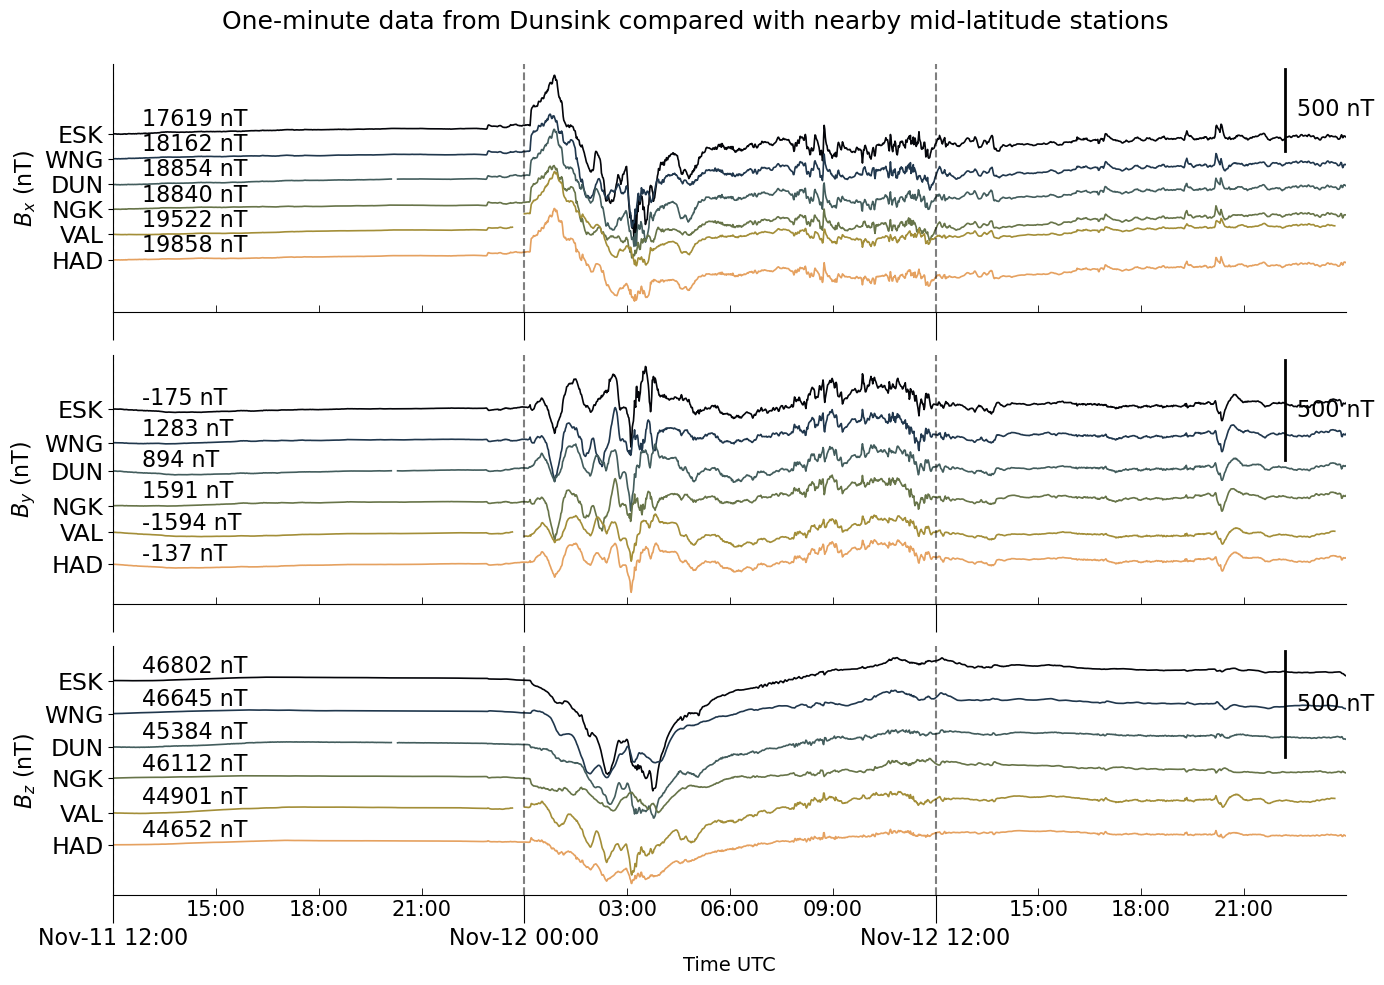

In [ ]:
padding_fraction = 0.15
component_list = ['X', 'Y', 'Z']
scale_length = 500 #scale bar to plot in nT
ylabels = ["$B_x$ (nT)", "$B_y$ (nT)", "$B_z$ (nT)"]
title = 'One-minute data from Dunsink compared with \
nearby mid-latitude stations'
file_name = 'Mid-Latitude_Nov11_halfday-12_Bxyz.png'

stack_plot(
        df_minute_obs, obs_plot_list, padding_fraction, component_list,
        means, scale_length, ylabels, title, file_name, output_file_path
        )

Plot the dB/dt first derivatives of each component (future installment of the code)